# Marani-Inspired: Sensitivity to Severe Epidemic Threshold

- **Summary**: This document tests the sensitivity of our method inspired by [Marani et al. (2021)](https://doi.org/10.1073/pnas.2105482118) to threshold selection for the generalizaed Pareto fit. 

- **Data Required:** `epidemics_marani_240816.xlsx`

- **Author**: Ganqi Li (ganqi.li.25@dartmouth.edu)
- **Updated**: Sep 10, 2024

In [67]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import quad
from scipy.stats import genpareto
from scipy.optimize import minimize

## repeated printouts
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [ ]:
# Set filepaths
rawdata_dir = Path("../../data/raw").resolve()
cleandata_dir = Path("../../data/clean").resolve()
figdir = Path("../../output/exceedance_figures").resolve()

## 0. Prepare respiratory viral epidemic data

In [68]:
## Read epidemic data from Marani et al. 
df = pd.read_excel(rawdata_dir / "epidemics_marani_240816.xlsx")
df = df.sort_values(by='year_start', ascending=True).reset_index(drop=True)

## Subset to respiratory viral epidemics
df_resp_viral = df[df['disease'].isin(['influenza', 'covid-19', 'mers', 'sars'])
                  ].reset_index(drop=True)


## 1. Set up exceedance probabilities from Madhav

In [69]:
## Read Madhav exceedance results from '03_resp_viral_comp'
df_madhav = pd.read_excel(cleandata_dir / "exceedance_results" / "madhav_original.xlsx")


In [70]:
## Set severeity points automatically 
plot_madhav_points = False  ## CHANGE METHOD HERE

if plot_madhav_points:
    severity = [0.01, 7.2, 28, 45, 86, 150, 200, 220, 250, 280]
else:
    severity = [0.01, 0.04, 0.07, 0.08, 0.1, 0.4, 0.7, 1, 4, 7, 8, 10, 
                15, 20, 28, 40, 45, 70, 86, 100, 120, 150, 170, 190, 
                200, 220, 230, 240, 250, 260, 270, 280]

## Set up severity points manually
# severity = df_madhav['severity']
# severity = [0.01, 7.2, 28, 45, 86, 150, 200, 220, 250, 280]

## 2. Calibrate the Marani-inspired method with a 0.1 SMU threshold

In [71]:
## Subset epidemic data to 1600-present
df_resp_viral_marani_inspired = df_resp_viral[(df_resp_viral["year_start"] >= 1600)].reset_index(drop=True)

## Set severity threshold to 0.01 SMU
thresh = 0.1

## Subset to threshold-exceeding respiratory viral epidemics
df_marani_inspired_exceed = df_resp_viral_marani_inspired[df_resp_viral_marani_inspired['severity_smu'] >= thresh].reset_index(drop=True)


In [72]:
## Display Marani-inspired data for GPD
df_marani_inspired_exceed 

,location,year_start,year_end,duration,death_thousand,pop_thousand,severity_perthousand,severity_smu,disease,type,transmission,is_vira_only,is_vira_mixed,contains_vira,is_pandemic
0,"pandemic, influenza",1781,1782,2,100.0,869840.0,0.114964,1.149637,influenza,viral,droplet,1,0,1,1
1,russian flu,1889,1890,2,1310.0,1497480.0,0.874803,8.748030,influenza,viral,droplet,1,0,1,1
2,pandemic spanish flu,1918,1920,3,32000.0,1873300.0,17.082154,170.821545,influenza,viral,droplet,1,0,1,1
3,pandemic of asian flu,1957,1958,2,2000.0,2873306.0,0.696062,6.960623,influenza,viral,droplet,1,0,1,1
4,hong kong flu,1968,1969,2,1000.0,3551599.0,0.281563,2.815633,influenza,viral,droplet,1,0,1,1
5,swine flu,2009,2009,1,284.5,6872767.0,0.041395,0.413953,influenza,viral,droplet,1,0,1,1
6,global covid-19,2019,2024,6,7100.0,7740000.0,0.917313,9.173127,covid-19,viral,airborne/droplet,1,0,1,1


In [73]:
## Fit generalized Pareto distribution on extreme epidemics
params_marani_inspired = genpareto.fit(df_marani_inspired_exceed['severity_smu'], floc=thresh)

## Print results
print(params_marani_inspired)

(1.2063663203389243, 0.1, 4.215552543135871)


In [74]:
## Find arrival rate of threshold-exceeding epidemics during 2000 to 2019
arrival_severe_marani_inspired = df_marani_inspired_exceed[(df_marani_inspired_exceed['year_start'] >= 2000) & 
                                                           (df_marani_inspired_exceed['year_start'] <= 2019)
                                                          ].shape[0] / 20

## Print arrival rate of threshold-exceeding events
print(f'Extreme epidemic arrival rate: {round(arrival_severe_marani_inspired, 3)}/year')


Extreme epidemic arrival rate: 0.1/year


In [75]:
## Update severeity with 0.1 SMU threshold 
severity = [0.1, 0.4, 0.7, 1, 4, 7, 8, 10, 15, 20, 28, 
            40, 45, 70, 86, 100, 120, 150, 170, 190, 
            200, 220, 230, 240, 250, 260, 270, 280]

In [76]:
## Calculate exceedance probabilities
exceedance = arrival_severe_marani_inspired * (1 - genpareto.cdf(severity, 
                                                                 *params_marani_inspired))

df_marani_inspired_thresh_alt1 = pd.DataFrame({
    "severity": severity,
    "exceedance": exceedance
})

## Sort and reset index (optional)
df_marani_inspired_thresh_alt1 = df_marani_inspired_thresh_alt1.sort_values(by='severity', ascending=True)
df_marani_inspired_thresh_alt1 = df_marani_inspired_thresh_alt1.reset_index(drop=True)


In [77]:
## Display exceedance results
df_marani_inspired_thresh_alt1


,severity,exceedance
0,0.1,0.100000
1,0.4,0.093400
2,0.7,0.087691
3,1.0,0.082699
4,4.0,0.053723
5,7.0,0.040510
6,8.0,0.037540
7,10.0,0.032830
8,15.0,0.025239
9,20.0,0.020678


## 3. Calibrate the Marani-inspired method with a 1 SMU threshold

In [78]:
## Subset epidemic data to 1600-present
df_resp_viral_marani_inspired = df_resp_viral[(df_resp_viral["year_start"] >= 1600)].reset_index(drop=True)

## Set severity threshold to 0.01 SMU
thresh = 1

## Subset to threshold-exceeding respiratory viral epidemics
df_marani_inspired_exceed = df_resp_viral_marani_inspired[df_resp_viral_marani_inspired['severity_smu'] >= thresh].reset_index(drop=True)


In [79]:
## Display Marani-inspired data for GPD
df_marani_inspired_exceed 


,location,year_start,year_end,duration,death_thousand,pop_thousand,severity_perthousand,severity_smu,disease,type,transmission,is_vira_only,is_vira_mixed,contains_vira,is_pandemic
0,"pandemic, influenza",1781,1782,2,100.0,869840.0,0.114964,1.149637,influenza,viral,droplet,1,0,1,1
1,russian flu,1889,1890,2,1310.0,1497480.0,0.874803,8.748030,influenza,viral,droplet,1,0,1,1
2,pandemic spanish flu,1918,1920,3,32000.0,1873300.0,17.082154,170.821545,influenza,viral,droplet,1,0,1,1
3,pandemic of asian flu,1957,1958,2,2000.0,2873306.0,0.696062,6.960623,influenza,viral,droplet,1,0,1,1
4,hong kong flu,1968,1969,2,1000.0,3551599.0,0.281563,2.815633,influenza,viral,droplet,1,0,1,1
5,global covid-19,2019,2024,6,7100.0,7740000.0,0.917313,9.173127,covid-19,viral,airborne/droplet,1,0,1,1


In [80]:
## Fit generalized Pareto distribution on extreme epidemics
params_marani_inspired = genpareto.fit(df_marani_inspired_exceed['severity_smu'], floc=thresh)

## Print results
print(params_marani_inspired)


(1.2810380472473857, 1, 4.540132914127435)


In [81]:
## Find arrival rate of threshold-exceeding epidemics during 2000 to 2019
arrival_severe_marani_inspired = df_marani_inspired_exceed[(df_marani_inspired_exceed['year_start'] >= 2000) & 
                                                           (df_marani_inspired_exceed['year_start'] <= 2019)
                                                          ].shape[0] / 20

## Print arrival rate of threshold-exceeding events
print(f'Extreme epidemic arrival rate: {round(arrival_severe_marani_inspired, 3)}/year')


Extreme epidemic arrival rate: 0.05/year


In [82]:
## Update severeity with 1 SMU threshold 
severity = [1, 4, 7, 8, 10, 15, 20, 28, 40, 45, 70, 
            86, 100, 120, 150, 170, 190, 200, 220, 
            230, 240, 250, 260, 270, 280]


In [83]:
## Calculate exceedance probabilities
exceedance = arrival_severe_marani_inspired * (1 - genpareto.cdf(severity, 
                                                                 *params_marani_inspired))

df_marani_inspired_thresh_alt2 = pd.DataFrame({
    "severity": severity,
    "exceedance": exceedance
})

## Sort and reset index (optional)
df_marani_inspired_thresh_alt2 = df_marani_inspired_thresh_alt2.sort_values(by='severity', ascending=True)
df_marani_inspired_thresh_alt2 = df_marani_inspired_thresh_alt2.reset_index(drop=True)


In [84]:
## Display exceedance results
df_marani_inspired_thresh_alt2


,severity,exceedance
0,1,0.050000
1,4,0.030978
2,7,0.023074
3,8,0.021347
4,10,0.018641
5,15,0.014346
6,20,0.011796
7,28,0.009306
8,40,0.007185
9,45,0.006588


# 4. Visualize results against Marani-Inspired with 0.001 SMU threshold and Madhav

In [85]:
## Read exceedance results from benchmark model
df_marani_inspired = pd.read_excel(cleandata_dir / "exceedance_results" / "marani_inspired.xlsx")

<Figure size 1000x600 with 0 Axes>

Text(0.5, 0, 'Epidemic severity (SMU = deaths per 10,000 people) (log scale)')

Text(0, 0.5, 'Annual exceedance probability (log scale)')

(0.0001, 1.0)

(0.01, 1000.0)

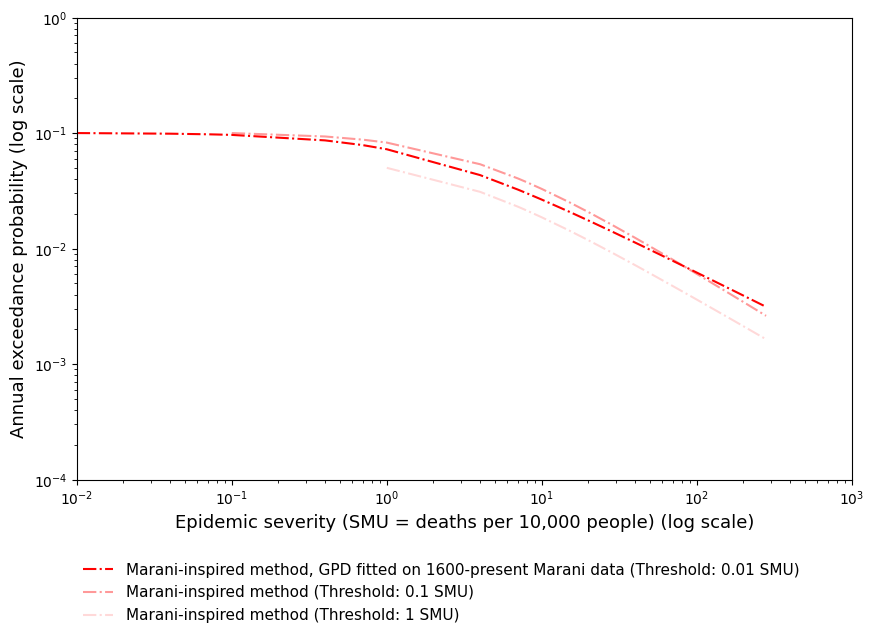

In [86]:
## Plot comparison across Marani with different thresholds 
plt.figure(figsize=(10, 6))

## Plot for Marani-inspired with 0.01 SMU threshold
plt.plot(df_marani_inspired['severity'], df_marani_inspired['exceedance'], 
         color='red', linestyle='-.', alpha=1,
         label='Marani-inspired method, GPD fitted on 1600-present Marani data (Threshold: 0.01 SMU)')

## Plot for Marani-inspired with 0.1 SMU threshold
plt.plot(df_marani_inspired_thresh_alt1['severity'], df_marani_inspired_thresh_alt1['exceedance'], 
         color='red', linestyle='-.', alpha=0.4,
         label='Marani-inspired method (Threshold: 0.1 SMU)')

## Plot for Marani-inspired with 1 SMU threshold
plt.plot(df_marani_inspired_thresh_alt2['severity'], df_marani_inspired_thresh_alt2['exceedance'], 
         color='red', linestyle='-.', alpha=0.15,
         label='Marani-inspired method (Threshold: 1 SMU)')



# ## Plot for Madhav
# plt.plot(df_madhav['severity'], df_madhav['exceedance'], 
#          color='purple', linestyle='-', label='Original simulated results from Madhav')

## Add labels and title
plt.xlabel('Epidemic severity (SMU = deaths per 10,000 people) (log scale)', fontsize=13)
plt.ylabel('Annual exceedance probability (log scale)', fontsize=13)
# plt.title('Marani-Inspired Method: Sensitivity to Severe Epidemic Threshold', fontsize=16)

## Set y-axis scale and limits
plt.yscale('log')
plt.ylim(1e-4, 1e0)

## Set x-axis scale and limits
plt.xscale('log')
plt.xlim(1e-2, 1e3)
# plt.xlim(0, 300)

## Adding legend below the plot in 1 column without frame
plt.legend(loc='upper center', bbox_to_anchor=(0.47, -0.15), 
           ncol=1, frameon=False, fontsize=11)

## Save graph as jpg file at 400 dpi
plt.savefig(figdir / '06e_sensitivity_gpd_thresh.jpg', dpi=400, bbox_inches = 'tight')

## Display
plt.show()
